### **[Plot Geospatial Maps Using Matplotlib](https://medium.com/the-visual-analyst/22afdaea748e)**

> *Exploring How Far Matplotlib Can Go Beyond Regular Charts.*

In [1]:
!apt-get install -qq libgdal-dev libgeos-dev libproj-dev
!pip install -qq matplotlib geopandas shapely
!pip install -qq cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 68.7 MB/s eta 0:00:00


#### **USA Cities Population Density Map Using Matplotlib**

In [2]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point

import cartopy.crs as ccrs
import cartopy.feature as cfeature

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'

%autosave 20

Autosaving every 20 seconds


In [3]:
# Load US state boundaries
url = 'https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json'
states = gpd.read_file(url)

display(states.head())
print(f"\nDataset shape: {states.shape}")

,id,name,density,geometry
0,01,Alabama,94.650,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847..."
1,02,Alaska,1.264,"MULTIPOLYGON (((-131.60202 55.11798, -131.5691..."
2,04,Arizona,57.050,"POLYGON ((-109.0425 37.00026, -109.04798 31.33..."
3,05,Arkansas,56.430,"POLYGON ((-94.47384 36.50186, -90.15254 36.496..."
4,06,California,241.700,"POLYGON ((-123.23326 42.00619, -122.37885 42.0..."



Dataset shape: (52, 4)


In [4]:
# Keep only the continental US states
states = states[~states['name'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

display(states)

,id,name,density,geometry
0,01,Alabama,94.650,"POLYGON ((-87.3593 35.00118, -85.60668 34.9847..."
2,04,Arizona,57.050,"POLYGON ((-109.0425 37.00026, -109.04798 31.33..."
3,05,Arkansas,56.430,"POLYGON ((-94.47384 36.50186, -90.15254 36.496..."
4,06,California,241.700,"POLYGON ((-123.23326 42.00619, -122.37885 42.0..."
5,08,Colorado,49.330,"POLYGON ((-107.91973 41.00391, -105.72895 40.9..."
6,09,Connecticut,739.100,"POLYGON ((-73.05353 42.03905, -71.79931 42.022..."
7,10,Delaware,464.300,"POLYGON ((-75.41409 39.80446, -75.5072 39.6839..."
8,11,District of Columbia,10065.000,"POLYGON ((-77.03526 38.99387, -76.90929 38.895..."
9,12,Florida,353.400,"POLYGON ((-85.49714 30.99754, -85.00421 31.003..."
10,13,Georgia,169.500,"POLYGON ((-83.10919 35.00118, -83.32279 34.787..."


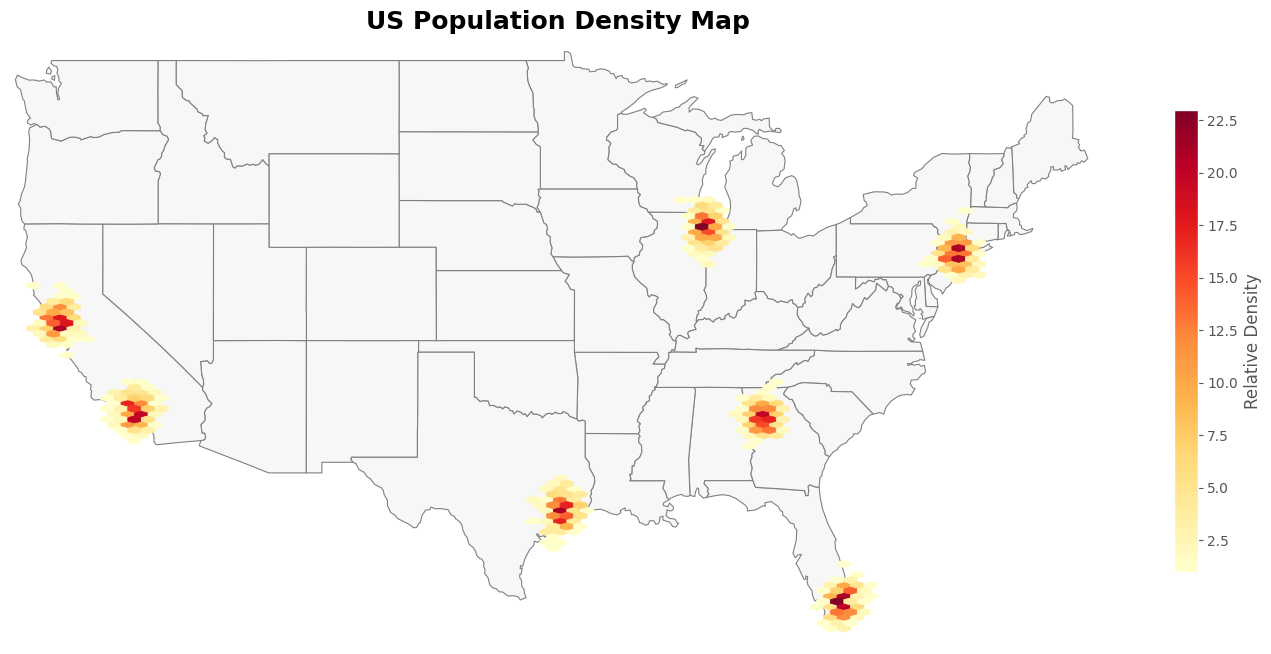

In [5]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 8))

# Draw the base map
states.plot(
  ax=ax,
  color='#F7F7F7',
  edgecolor='gray',
  linewidth=0.8
)

# Define cities and generate points
cities = [
  (-74.0, 40.7),   # NYC
  (-118.2, 34.0),  # LA
  (-87.6, 41.8),   # Chicago
  (-95.3, 29.7),   # Houston
  (-122.4, 37.8),  # SF
  (-84.4, 33.7),   # Atlanta
  (-80.2, 25.8),   # Miami
]
points = []

for lon, lat in cities:
  for _ in range(200):
    points.append(
      Point(np.random.normal(lon, 0.5), np.random.normal(lat, 0.5))
    )

points = GeoDataFrame(geometry=points)

# Plot the hexbin density
hb = ax.hexbin(
  points.geometry.x,
  points.geometry.y,
  gridsize=70,
  cmap="YlOrRd",
  mincnt=1
)

# Final styling
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_title(
  "US Population Density Map",
  fontsize=18,
  weight="bold"
)
ax.axis("off")

# Add a colorbar for context
plt.colorbar(hb, ax=ax, label='Relative Density', shrink=0.6)

plt.tight_layout()
plt.show()

#### **United States Topographic Relief Map in Matplotlib**

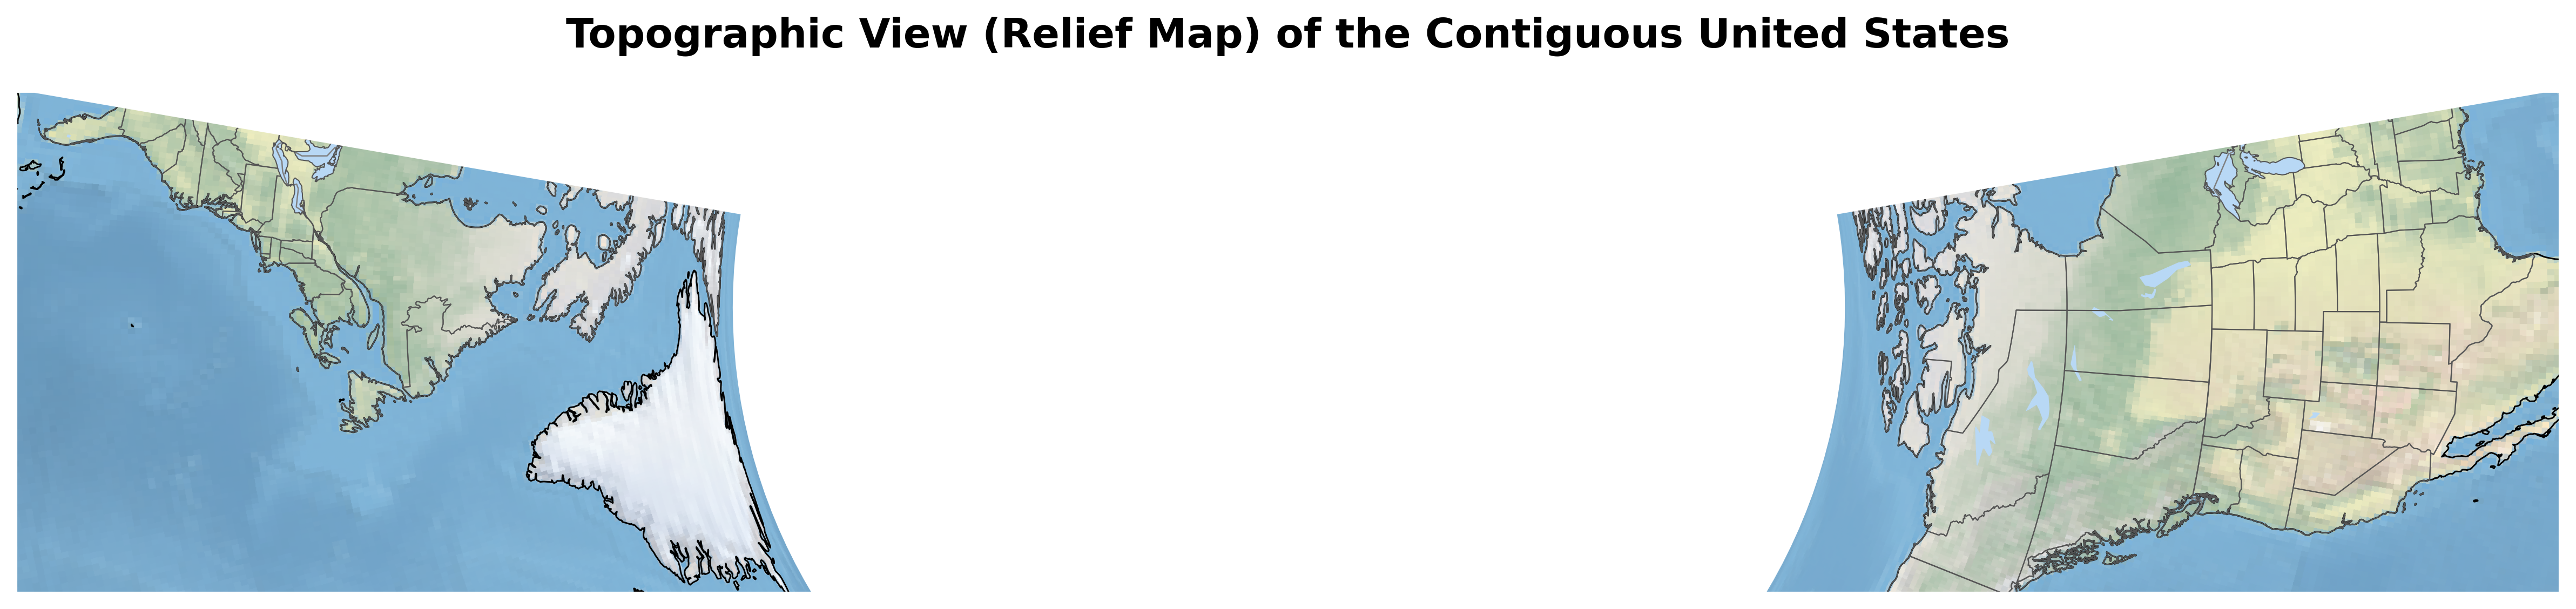

In [6]:
# Create figure
fig = plt.figure(figsize=(16, 9), dpi=300)

# Choose a map projection
ax = plt.axes(
  projection=ccrs.AlbersEqualArea(
    central_latitude=37.5,
    central_longitude=96
  )
)

# Focus on the continuous US state boundaries
ax.set_extent(
  [-125, -66.5, 24, 50],
  crs=ccrs.PlateCarree()
)

# Add the terrain background
ax.stock_img()

# Land and water
ax.add_feature(cfeature.LAND, facecolor='#f7f4ea')
ax.add_feature(cfeature.OCEAN, facecolor='#b8d8f5')
ax.add_feature(cfeature.LAKES, facecolor='#b8d8f5')

# Coastlines
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7, edgecolor='black')

# Country borders
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.6, edgecolor="gray")

# State boundaries
ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.5, edgecolor="#555555")

plt.title(
  "Topographic View (Relief Map) of the Contiguous United States",
  fontsize=18,
  weight="bold",
  pad=20
)

plt.tight_layout()
plt.show()

#### **Visualizing Major US Airline Routes with Matplotlib**

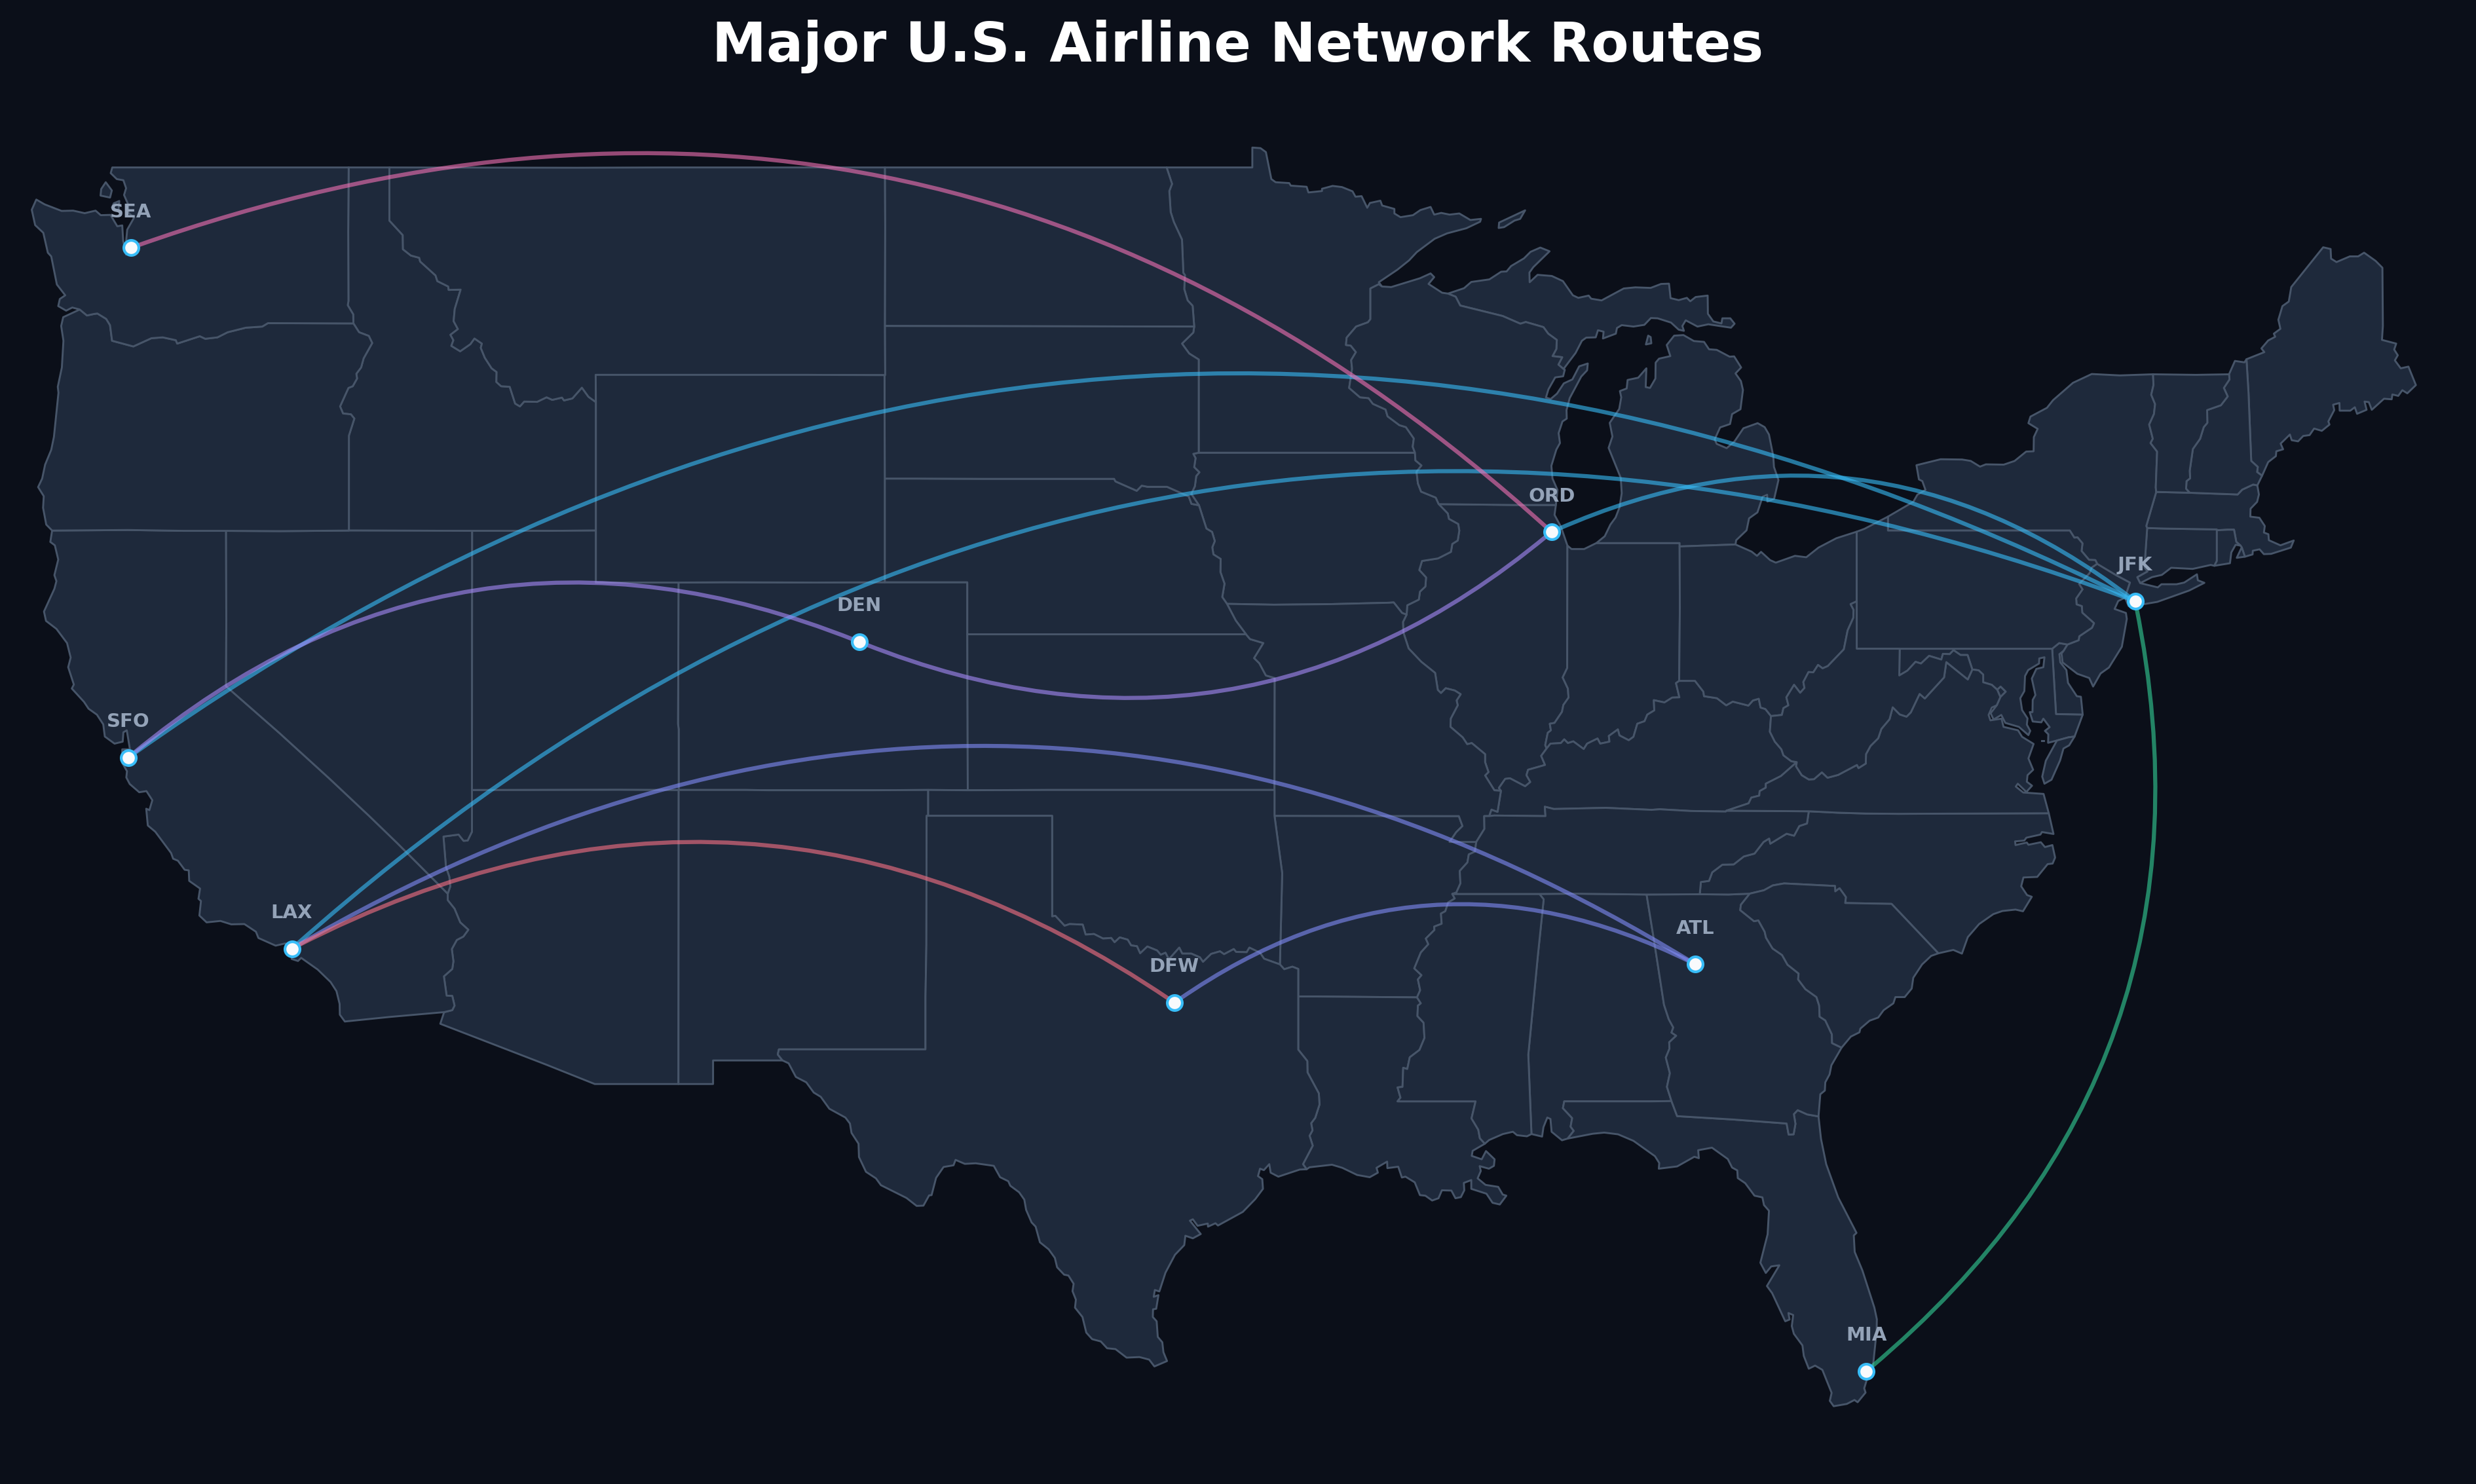

In [7]:
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
states = gpd.read_file(url)

states = states[~states["name"].isin(["Alaska", "Hawaii", "Puerto Rico"])]

# Create figure
fig, ax = plt.subplots(figsize=(16, 9), dpi=300)

fig.patch.set_facecolor("#0B0F19")
ax.set_facecolor("#0B0F19")

# Draw the base map
states.plot(
  ax=ax,
  color="#1E293B",
  edgecolor="#475569",
  linewidth=0.7
)

# Airport hubs coordinates (Longitude, Latitude)
hubs = {
    "JFK": (-73.7781, 40.6413),
    "LAX": (-118.4085, 33.9416),
    "ORD": (-87.9073, 41.9742),
    "ATL": (-84.4277, 33.6407),
    "DFW": (-97.0403, 32.8998),
    "SFO": (-122.3748, 37.6213),
    "MIA": (-80.2870, 25.7959),
    "SEA": (-122.3088, 47.4502),
    "DEN": (-104.6737, 39.8561)
}

# Define routes (Start Hub, End Hub, Color)
routes = [
    (hubs["JFK"], hubs["LAX"], "#38BDF8"),
    (hubs["JFK"], hubs["SFO"], "#38BDF8"),
    (hubs["JFK"], hubs["ORD"], "#38BDF8"),
    (hubs["ATL"], hubs["LAX"], "#818CF8"),
    (hubs["ATL"], hubs["DFW"], "#818CF8"),
    (hubs["ORD"], hubs["SEA"], "#F472B6"),
    (hubs["DFW"], hubs["LAX"], "#FB7185"),
    (hubs["MIA"], hubs["JFK"], "#34D399"),
    (hubs["DEN"], hubs["SFO"], "#A78BFA"),
    (hubs["DEN"], hubs["ORD"], "#A78BFA")
]

# Draw curved airline routes
for start, end, color in routes:
  ax.annotate(
    "",
    xy=end,
    xytext=start,
    arrowprops=dict(
      arrowstyle="-",
      lw=1.5,
      color=color,
      alpha=0.6,
      connectionstyle="arc3,rad=0.3"
    )
  )

# Plot airport locations
for name, (x, y) in hubs.items():
  ax.scatter(x, y, s=30, color="#F8FAFC", zorder=5, edgecolors="#38BDF8", linewidth=1)
  ax.text(x, y + 0.6, name, color="#94A3B8", fontsize=7, ha="center", weight="bold")

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.axis("off")

plt.title("Major U.S. Airline Network Routes", color="white", fontsize=20, pad=20)

plt.show()